### Simple Data Exploration for Resume Dataset

In [115]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [116]:
# load data

# local csv file
df = pd.read_csv('resume_data.csv')

# remove bom character and whitespace from column names
df.columns = df.columns.str.strip().str.replace('﻿', '', regex=False)

# drop duplicate column
df = df.drop(columns=['responsibilities.1'])

# strip leading/trailing whitespace from all string values
df = df.map(lambda x: x.strip() if isinstance(x, str) else x)

# normalize all string values to lowercase
df = df.map(lambda x: x.lower() if isinstance(x, str) else x)

# replace empty strings and n/a with None
df = df.replace({'': None, 'n/a': None})

In [117]:
# simple info

# dataset dimensions
print(f"dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

# top 3 most frequent values per column
for col in df.columns:
    print(f"\n--- {col} ---")

    # get top 3 most common values, excluding null/none
    top = df[col].dropna().value_counts().head(3)

    # if length is 0, then print no data
    if len(top) == 0:
        print("no data")

    # if all counts are the same, just show first 3 unique values
    elif top.iloc[0] == top.iloc[-1]:
        for val in top.index[:3]:
            print(str(val).replace('\n', ' '))

    # show value and how many times it appears
    else:
        for val, count in top.items():
            print(f"{val!r}: {count} occurrences")

dataset shape: 9544 rows, 34 columns

--- address ---
sunnyvale, ca
trenton, nj
malvern, pa

--- career_objective ---
big data analytics working and database warehouse manager with robust experience in handling all kinds of data. i have also used multiple cloud infrastructure services and am well acquainted with them. currently in search of role that offers more of development.
to utilize my customer relations and management background to obtain a position with a company that places importance on efficiency and success. employ natural leadership and interpersonal skills to build relationships throughout the organization.
fresher python developer interested in data analytics and machine learning.

--- skills ---
'[]': 56 occurrences
"['python', 'mysql', 'tensorflow', 'keras', 'machine learning', 'deep learning']": 56 occurrences
"['big data', 'hadoop', 'hive', 'python', 'mapreduce', 'spark', 'java', 'machine learning', 'cloud', 'hdfs', 'yarn', 'core java', 'data science', 'c++', 'data s

In [118]:
# missing values

# count missing values per column, sorted from most to least
missing = df.isnull().sum().sort_values(ascending=False)

# convert to percentage
missing_pct = (missing / len(df) * 100).round(1)

# combine and print
missing_df = pd.DataFrame({'missing count': missing, 'missing %': missing_pct})
print(missing_df)

                                     missing count  missing %
proficiency_levels                            8844       92.7
languages                                     8844       92.7
address                                       8760       91.8
expiry_dates                                  7536       79.0
issue_dates                                   7536       79.0
online_links                                  7536       79.0
certification_skills                          7536       79.0
certification_providers                       7536       79.0
extra_curricular_organization_names           6118       64.1
role_positions                                6118       64.1
extra_curricular_organization_links           6118       64.1
extra_curricular_activity_types               6118       64.1
career_objective                              4804       50.3
age_requirement                               4087       42.8
skills_required                               1701       17.8
experien

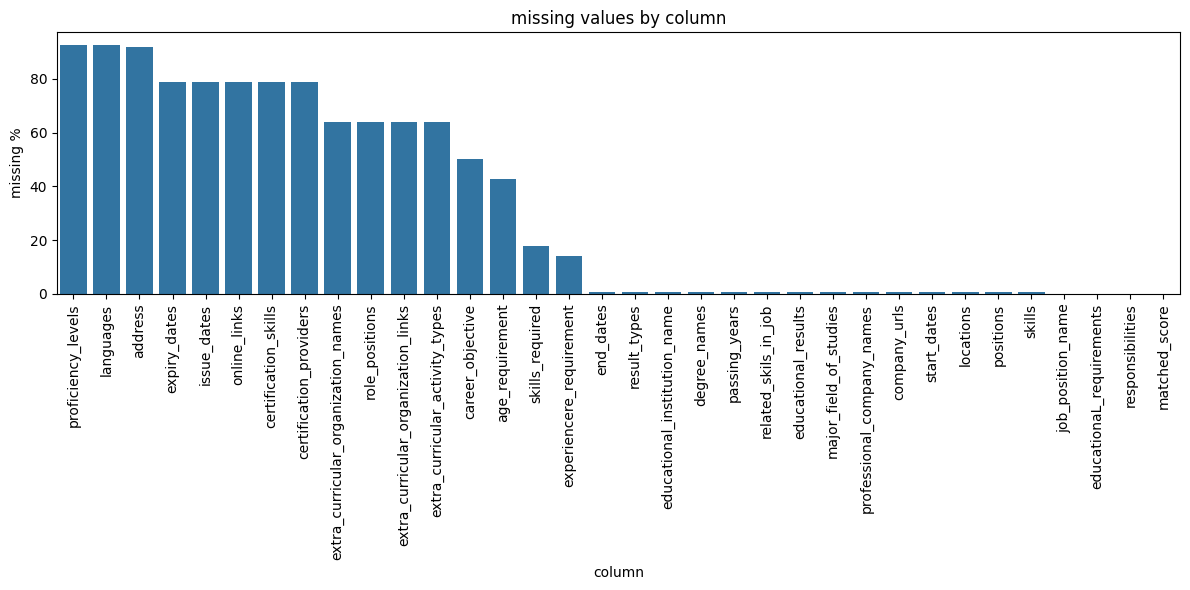

In [119]:
# missing values chart

plt.figure(figsize=(12, 6))

# bar chart of missing % per column
sns.barplot(x=missing_pct.index, y=missing_pct.values)

plt.xticks(rotation=90)

# axis labels and title
plt.xlabel('column')
plt.ylabel('missing %')
plt.title('missing values by column')
plt.tight_layout()
plt.show()